## https://github.com/2Myaka2/DataScience_projects

### работал в репозитории

# **Нелинейные модели против южной погоды**


## Описание проекта

Компания **BikeSouth** развивает городской велопрокат на юге России и хочет улучшить систему прогнозирования спроса на аренду велосипедов. Для бизнеса важно заранее понимать, сколько велосипедов потребуется в каждый конкретный час, чтобы эффективнее распределять велосипеды между станциями, снижать количество простоев и избегать ситуаций, когда клиент не может арендовать велосипед из-за дефицита.

Ранее компания использовала базовую модель на основе **линейной регрессии**, однако её качество оказалось недостаточным. Вероятная причина заключается в том, что спрос на велосипеды зависит не только от отдельных факторов, но и от их сочетаний: температуры, влажности, осадков, солнечной активности, времени суток, сезона и праздничных дней. Такие зависимости могут быть нелинейными, поэтому в проекте будут рассмотрены более гибкие модели машинного обучения.

## Цель проекта

Разработать модель машинного обучения, которая предсказывает значение целевой переменной:

**`Rented Bike Count`** — количество арендованных велосипедов за конкретный час.

Модель должна учитывать погодные и календарные признаки и показывать качество выше, чем предоставленная baseline-модель на основе линейной регрессии.

## Задачи проекта

В рамках проекта необходимо:

1. Загрузить тренировочную и тестовую выборки.
2. Загрузить предоставленный baseline-пайплайн с линейной регрессией из `.pkl`-файла.
3. Оценить качество baseline-модели на train и test по метрикам:
   - RMSE;
   - MAE;
   - R².
4. Провести первичный анализ данных:
   - проверить типы признаков;
   - изучить пропуски;
   - оценить уникальные значения;
   - проверить распределение целевой переменной.
5. Выполнить EDA и сформулировать гипотезы о факторах, влияющих на спрос.
6. Подготовить данные для обучения моделей без утечки данных.
7. Обучить две нелинейные модели:
   - `KNeighborsRegressor`;
   - `DecisionTreeRegressor`.
8. Подобрать гиперпараметры для обеих моделей с помощью `Optuna`.
9. Использовать единую схему кросс-валидации с 5 фолдами.
10. Сравнить лучшие версии моделей по метрикам RMSE, MAE и R².
11. Выбрать лучшую модель и один раз проверить её на тестовой выборке.
12. Сравнить итоговое качество лучшей модели с baseline-моделью.
13. Проанализировать важность признаков и сделать выводы для бизнеса.

## Особенности валидации

Тестовая выборка используется только для финальной оценки качества модели.  
Она не применяется при обучении, подборе гиперпараметров и выборе модели.

Для подбора гиперпараметров и сравнения моделей используется кросс-валидация на тренировочной выборке.

Основная метрика оптимизации:

**RMSE** — корень из среднеквадратичной ошибки.

Чем ниже RMSE и MAE, тем лучше модель.  
Чем выше R², тем лучше модель объясняет вариативность целевой переменной.

## Используемые модели

В проекте будут обучены и сравнены следующие модели:

- **Baseline Linear Regression** — предоставленная модель компании BikeSouth.
- **kNN Regressor** — модель на основе ближайших соседей.
- **Decision Tree Regressor** — дерево решений для задачи регрессии.

## Ожидаемый результат

Итогом проекта должна стать модель, которая лучше baseline-модели прогнозирует почасовой спрос на аренду велосипедов. Полученные результаты могут помочь BikeSouth:

- точнее планировать количество доступных велосипедов;
- улучшать логистику перераспределения велосипедов;
- снижать риск дефицита велосипедов в часы повышенного спроса;
- повышать качество клиентского опыта.

In [2]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1
scikit-learn==1.6.1
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3
ipykernel==6.29.5
optuna==4.4.0

Overwriting requirements.txt


In [ ]:
# Базовые библиотеки
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn: базовые инструменты
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    cross_validate
)

# sklearn: предобработка
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# sklearn: модели
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

# sklearn: метрики
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    make_scorer
)

# sklearn: интерпретация
from sklearn.inspection import permutation_importance

import optuna

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CV_FOLDS = 5
TARGET = "Rented Bike Count"

/home/andre/DS/DataScience_projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Загрузка данных

REMOTE_DATA_URL = "https://code.s3.yandex.net/datasets/"

file_names = {
    "train": "ds_s14_train_data.csv",
    "test": "ds_s14_test_data.csv",
}

dataframes = {}

for name, file_name in file_names.items():
    local_path = Path("datasets") / file_name          # локальная папка проекта
    practicum_path = Path("/datasets") / file_name     # путь на платформе Практикума
    remote_path = REMOTE_DATA_URL + file_name          # удалённый путь
    
    try:
        dataframes[name] = pd.read_csv(local_path)
        print(f"{name}: загружен из локальной папки {local_path}")
    except FileNotFoundError:
        try:
            dataframes[name] = pd.read_csv(practicum_path)
            print(f"{name}: загружен из папки Практикума {practicum_path}")
        except FileNotFoundError:
            dataframes[name] = pd.read_csv(remote_path)
            print(f"{name}: загружен из удалённого хранилища {remote_path}")

df_train = dataframes["train"]
df_test = dataframes["test"]

print()
print(f"Размер тренировочной выборки: {df_train.shape}")
print(f"Размер тестовой выборки: {df_test.shape}")

train: загружен из локальной папки datasets/ds_s14_train_data.csv
test: загружен из локальной папки datasets/ds_s14_test_data.csv

Размер тренировочной выборки: (7008, 16)
Размер тестовой выборки: (1752, 16)


In [5]:
df_mains = {
    'df_train': df_train,
    'df_test': df_test
}

In [6]:
def show_df_info(name, df):
    print('=' * 80)
    print(f'Датасет: {name}')
    print('=' * 80)
    
    print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
    
    print('\nИнформация о типах данных:')
    df.info()
    
    print('\nПервые 5 строк:')
    display(df.head())
    
    print('\nКоличество пропусков:')
    display(df.isna().sum().to_frame(name='missing_values'))
    
    print('\nКоличество явных дубликатов:')
    print(df.duplicated().sum())
    
    print('\n')

for name, df in df_mains.items():
    show_df_info(name, df)

Датасет: df_train
Размер: 7008 строк, 16 столбцов

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null 

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.300,35.000,2.400,2000.000,4.300,0.460,0.000,0.000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.400,55.000,3.200,2000.000,15.600,0.150,0.000,0.000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.900,39.000,1.600,2000.000,-18.500,0.000,0.000,0.000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.200,37.000,2.200,2000.000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.400,34.000,2.100,2000.000,6.600,2.840,0.000,0.000,Autumn,No Holiday,Yes,False,False,False,False,1686



Количество пропусков:


,missing_values
Temperature,0
Humidity(%),250
Wind speed (m/s),210
Visibility (10m),259
Dew point temperature,0
Solar Radiation (MJ/m2),210
Rainfall(mm),262
Snowfall (cm),263
Seasons,0
Holiday,0



Количество явных дубликатов:
0


Датасет: df_test
Размер: 1752 строк, 16 столбцов

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Pe

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.700,48.000,0.800,817.000,-3.500,0.390,0.000,0.000,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.300,90.000,1.100,311.000,-6.600,0.000,0.000,2.200,Winter,No Holiday,Yes,False,False,True,False,178
2,2.900,66.000,1.200,173.000,-2.800,0.000,0.000,0.000,Winter,No Holiday,Yes,False,True,False,False,219
3,23.100,63.000,2.600,949.000,15.600,1.680,0.000,0.000,Spring,No Holiday,Yes,False,False,False,False,949
4,23.300,43.000,1.200,1257.000,10.000,1.910,0.000,0.000,Summer,No Holiday,Yes,False,False,True,False,1005



Количество пропусков:


,missing_values
Temperature,0
Humidity(%),72
Wind speed (m/s),52
Visibility (10m),72
Dew point temperature,0
Solar Radiation (MJ/m2),52
Rainfall(mm),64
Snowfall (cm),61
Seasons,0
Holiday,0



Количество явных дубликатов:
0




### Вывод по загрузке и первичной проверке данных

Были загружены две выборки:

- тренировочная выборка `df_train`: **7008 строк и 16 столбцов**;
- тестовая выборка `df_test`: **1752 строки и 16 столбцов**.

Обе таблицы имеют одинаковую структуру признаков. В данных присутствуют:

- **8 числовых погодных признаков** типа `float64`;
- **3 категориальных признака** типа `object`: `Seasons`, `Holiday`, `Functioning Day`;
- **4 булевых признака**, описывающих период суток;
- целевая переменная `Rented Bike Count`.

Целевая переменная присутствует в обеих выборках и не содержит пропусков. Явные дубликаты в тренировочной и тестовой выборках отсутствуют.

В нескольких погодных признаках обнаружены пропуски:

- `Humidity(%)`;
- `Wind speed (m/s)`;
- `Visibility (10m)`;
- `Solar Radiation (MJ/m2)`;
- `Rainfall(mm)`;
- `Snowfall (cm)`.

На данном этапе данные готовы для проверки baseline-модели. Полноценный исследовательский анализ, визуализации и генерация новых признаков будут выполнены после оценки качества предоставленной линейной модели.

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.

In [7]:
X_train = df_train.drop(columns=TARGET)
y_train = df_train[TARGET]

X_test = df_test.drop(columns=TARGET)
y_test = df_test[TARGET]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (7008, 15)
y_train: (7008,)
X_test: (1752, 15)
y_test: (1752,)


In [8]:
# Загрузка baseline-модели

baseline_file_name = "baseline_linear_regression_pipeline.pkl"

baseline_model_path = Path("artifacts") / baseline_file_name

if baseline_model_path is None:
    raise FileNotFoundError(
        "Файл baseline_linear_regression_pipeline.pkl не найден. "
        "Проверьте, что он находится в папке artifacts."
    )

baseline_model = joblib.load(baseline_model_path)

print(f"Baseline-модель загружена из: {baseline_model_path}")
print(f"Тип объекта: {type(baseline_model)}")

Baseline-модель загружена из: artifacts/baseline_linear_regression_pipeline.pkl
Тип объекта: <class 'sklearn.pipeline.Pipeline'>


In [9]:
# Краткая проверка структуры baseline-пайплайна

baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

In [10]:
# Функция для расчёта метрик качества

def calculate_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [11]:
# Получение предсказаний baseline-модели

baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)

print("Предсказания baseline-модели получены.")

Предсказания baseline-модели получены.


In [12]:
# Расчёт метрик baseline-модели

baseline_metrics = pd.DataFrame(
    [
        {
            "model": "Baseline Linear Regression",
            "sample": "train",
            **calculate_metrics(y_train, baseline_train_pred)
        },
        {
            "model": "Baseline Linear Regression",
            "sample": "test",
            **calculate_metrics(y_test, baseline_test_pred)
        }
    ]
)

baseline_metrics

,model,sample,RMSE,MAE,R2
0,Baseline Linear Regression,train,412.526,309.078,0.593
1,Baseline Linear Regression,test,411.564,312.599,0.586


Описание ошибок baseline-модели на тестовой выборке:


count    1752.000
mean      -14.607
std       411.422
min     -1185.811
25%      -283.695
50%       -45.793
75%       203.323
max      1892.882
Name: Rented Bike Count, dtype: float64

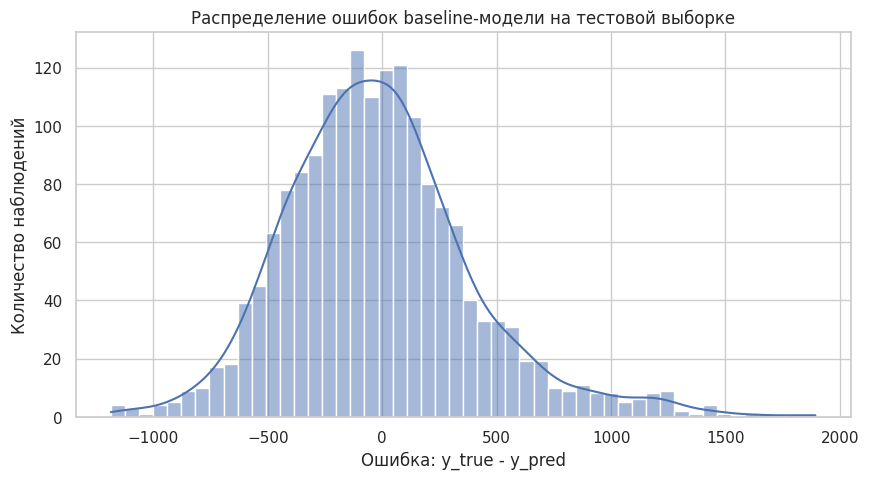

In [13]:
# Дополнительная проверка распределения ошибок baseline-модели

baseline_test_errors = y_test - baseline_test_pred

print("Описание ошибок baseline-модели на тестовой выборке:")
display(pd.Series(baseline_test_errors).describe())

plt.figure(figsize=(10, 5))
sns.histplot(baseline_test_errors, bins=50, kde=True)
plt.title("Распределение ошибок baseline-модели на тестовой выборке")
plt.xlabel("Ошибка: y_true - y_pred")
plt.ylabel("Количество наблюдений")
plt.show()

### Вывод по baseline-модели

Baseline-модель на основе линейной регрессии была успешно загружена из `.pkl`-файла и применена к тренировочной и тестовой выборкам без дополнительного обучения.

Качество baseline-модели:

| Выборка | RMSE | MAE | R² |
|---|---:|---:|---:|
| Train | 412.526 | 309.078 | 0.593 |
| Test | 411.564 | 312.599 | 0.586 |

Значения метрик на тренировочной и тестовой выборках очень близки. Это говорит о том, что baseline-модель не демонстрирует выраженного переобучения: качество на новых данных почти не отличается от качества на обучающих данных.

При этом абсолютный уровень ошибок достаточно высокий:

- средняя абсолютная ошибка на тестовой выборке составляет около **313 велосипедов**;
- RMSE на тестовой выборке составляет около **412 велосипедов**;
- коэффициент детерминации `R² = 0.586`, то есть модель объясняет примерно **59% вариативности спроса**.

Анализ ошибок на тестовой выборке показывает, что средняя ошибка равна **-14.607**. Поскольку ошибка считалась как `y_true - y_pred`, отрицательное среднее значение означает, что модель в среднем немного завышает прогноз. Однако это смещение небольшое относительно общего масштаба ошибки.

Распределение ошибок достаточно широкое:

- минимальная ошибка: **-1185.811**;
- максимальная ошибка: **1892.882**;
- медианная ошибка: **-45.793**.

Это означает, что в отдельных наблюдениях baseline-модель может ошибаться более чем на тысячу велосипедов. Вероятно, линейная регрессия недостаточно хорошо учитывает нелинейные зависимости между спросом и погодными или календарными факторами: температурой, влажностью, осадками, сезоном и временем суток.

Таким образом, baseline-модель можно использовать как отправную точку для сравнения. В следующих частях проекта будут обучены более гибкие нелинейные модели — `KNeighborsRegressor` и `DecisionTreeRegressor`. Их задача — снизить RMSE и MAE, а также повысить R² по сравнению с baseline-моделью.

## **Часть 2. Улучшение модели — kNN и дерево решений**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.



---



In [14]:
eda_df = df_train.copy()

num_features = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 
                'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
cat_features = ['Seasons', 'Holiday', 'Functioning Day']
binary_features = ['Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']

print("Числовые признаки:")
display(num_features)

print("Категориальные признаки:")
display(cat_features)

print("Бинарные признаки:")
display(binary_features)

Числовые признаки:


['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)']

Категориальные признаки:


['Seasons', 'Holiday', 'Functioning Day']

Бинарные признаки:


['Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night']

In [15]:
# Описательная статистика целевой переменной

target_description = eda_df[TARGET].describe()
target_description

count   7008.000
mean     705.606
std      646.312
min        0.000
25%      190.750
50%      504.500
75%     1070.000
max     3556.000
Name: Rented Bike Count, dtype: float64

In [16]:
# Доля нулевого спроса

zero_target_count = (eda_df[TARGET] == 0).sum()
zero_target_share = zero_target_count / len(eda_df)

print(f"Количество наблюдений с нулевым спросом: {zero_target_count}")
print(f"Доля наблюдений с нулевым спросом: {zero_target_share:.2%}")

Количество наблюдений с нулевым спросом: 242
Доля наблюдений с нулевым спросом: 3.45%


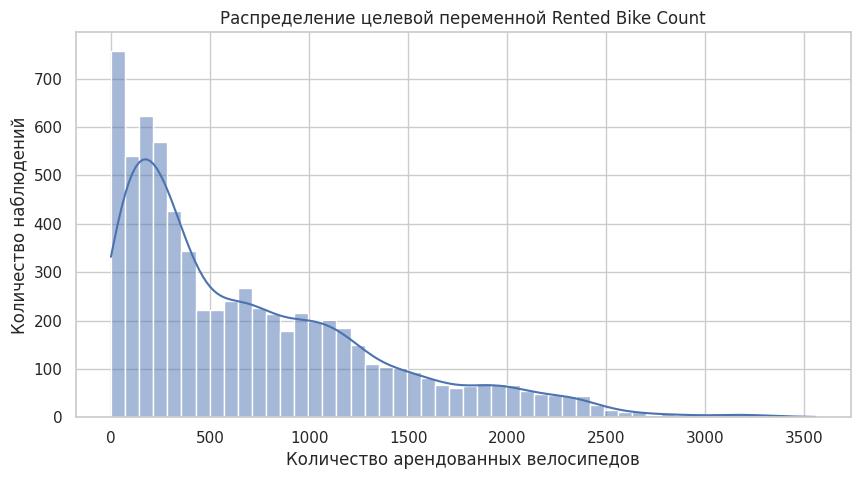

In [17]:
# Распределение целевой переменной

plt.figure(figsize=(10, 5))
sns.histplot(eda_df[TARGET], bins=50, kde=True)
plt.title("Распределение целевой переменной Rented Bike Count")
plt.xlabel("Количество арендованных велосипедов")
plt.ylabel("Количество наблюдений")
plt.show()

In [18]:
# Описательная статистика спроса по сезонам

season_target_stats = (
    eda_df
    .groupby("Seasons")[TARGET]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

season_target_stats

,count,mean,median,std,min,max
Seasons,,,,,,
Summer,1744,1046.247,923.000,690.317,9,3556
Autumn,1770,820.644,764.000,654.288,0,3298
Spring,1758,725.046,578.500,619.595,0,3251
Winter,1736,226.418,204.000,150.824,3,937


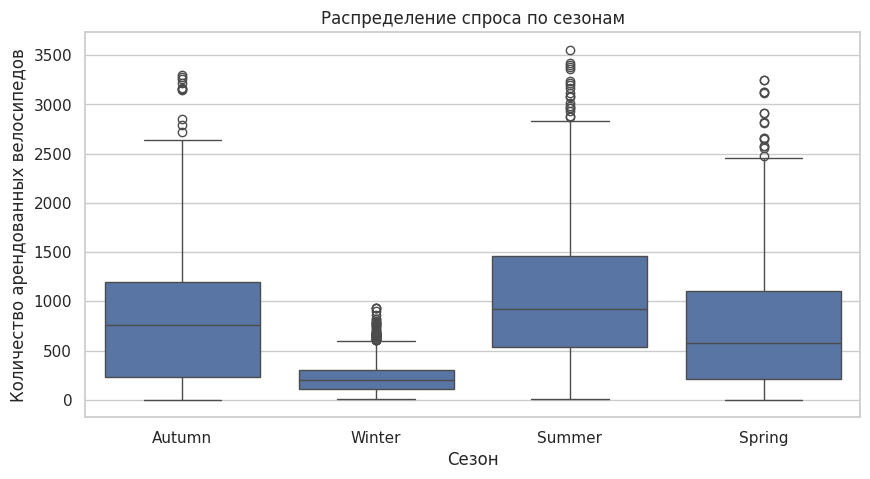

In [19]:
# Распределение спроса по сезонам

plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x="Seasons", y=TARGET)
plt.title("Распределение спроса по сезонам")
plt.xlabel("Сезон")
plt.ylabel("Количество арендованных велосипедов")
plt.show()

In [20]:
# Описательная статистика спроса по праздничным дням

holiday_target_stats = (
    eda_df
    .groupby("Holiday")[TARGET]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

holiday_target_stats

,count,mean,median,std,min,max
Holiday,,,,,,
No Holiday,6668,716.402,524.000,648.199,0,3556
Holiday,340,493.879,228.500,568.895,0,2400


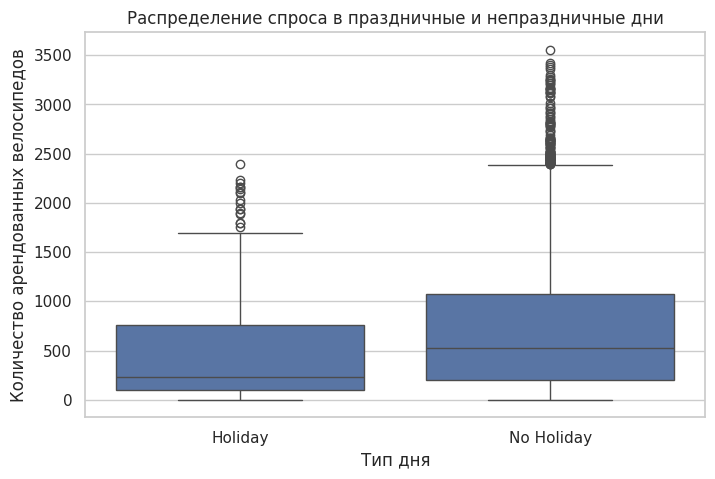

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="Holiday", y=TARGET)
plt.title("Распределение спроса в праздничные и непраздничные дни")
plt.xlabel("Тип дня")
plt.ylabel("Количество арендованных велосипедов")
plt.show()

In [22]:
# Проверим связь Functioning Day с целевой переменной

functioning_day_stats = (
    eda_df
    .groupby("Functioning Day")[TARGET]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

functioning_day_stats

,count,mean,median,std,min,max
Functioning Day,,,,,,
Yes,6766,730.843,546.000,643.595,2,3556
No,242,0.000,0.000,0.000,0,0


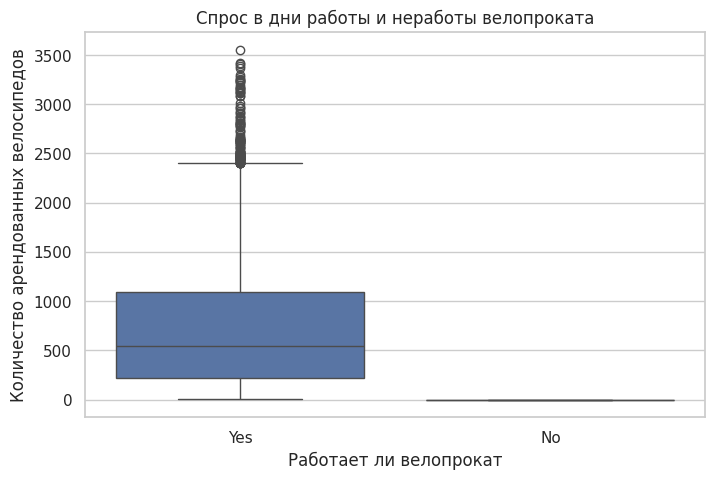

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="Functioning Day", y=TARGET)
plt.title("Спрос в дни работы и неработы велопроката")
plt.xlabel("Работает ли велопрокат")
plt.ylabel("Количество арендованных велосипедов")
plt.show()

In [24]:
# Создадим вспомогательный признак периода суток (только для EDA)

def get_time_period(row):
    if row["Time_Period_Morning"]:
        return "Morning"
    if row["Time_Period_Evening"]:
        return "Evening"
    if row["Time_Period_Late Evening"]:
        return "Late Evening"
    if row["Time_Period_Night"]:
        return "Night"
    return "Other"

eda_df["Time_Period"] = eda_df.apply(get_time_period, axis=1)

time_period_stats = (
    eda_df
    .groupby("Time_Period")[TARGET]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

time_period_stats

,count,mean,median,std,min,max
Time_Period,,,,,,
Evening,1168,1193.979,1154.000,857.755,0,3556
Late Evening,1173,927.049,894.000,694.010,0,2556
Other,1742,689.870,685.000,450.690,0,2329
Morning,1172,644.338,486.000,570.460,0,2495
Night,1753,288.632,202.000,265.421,0,1394


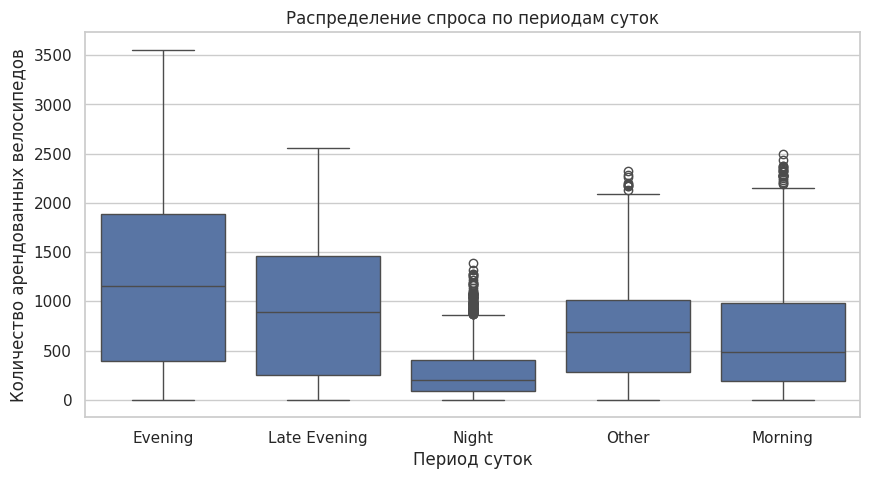

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x="Time_Period", y=TARGET)
plt.title("Распределение спроса по периодам суток")
plt.xlabel("Период суток")
plt.ylabel("Количество арендованных велосипедов")
plt.show()

In [26]:
# Корреляция числовых и бинарных признаков с целевой переменной

corr_features = num_features + binary_features

correlation_with_target = (
    eda_df[corr_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

correlation_with_target

Temperature                 0.541
Dew point temperature       0.387
Time_Period_Night          -0.373
Time_Period_Evening         0.338
Solar Radiation (MJ/m2)     0.257
Visibility (10m)            0.198
Humidity(%)                -0.190
Time_Period_Late Evening    0.154
Snowfall (cm)              -0.141
Rainfall(mm)               -0.118
Wind speed (m/s)            0.111
Time_Period_Morning        -0.042
Name: Rented Bike Count, dtype: float64

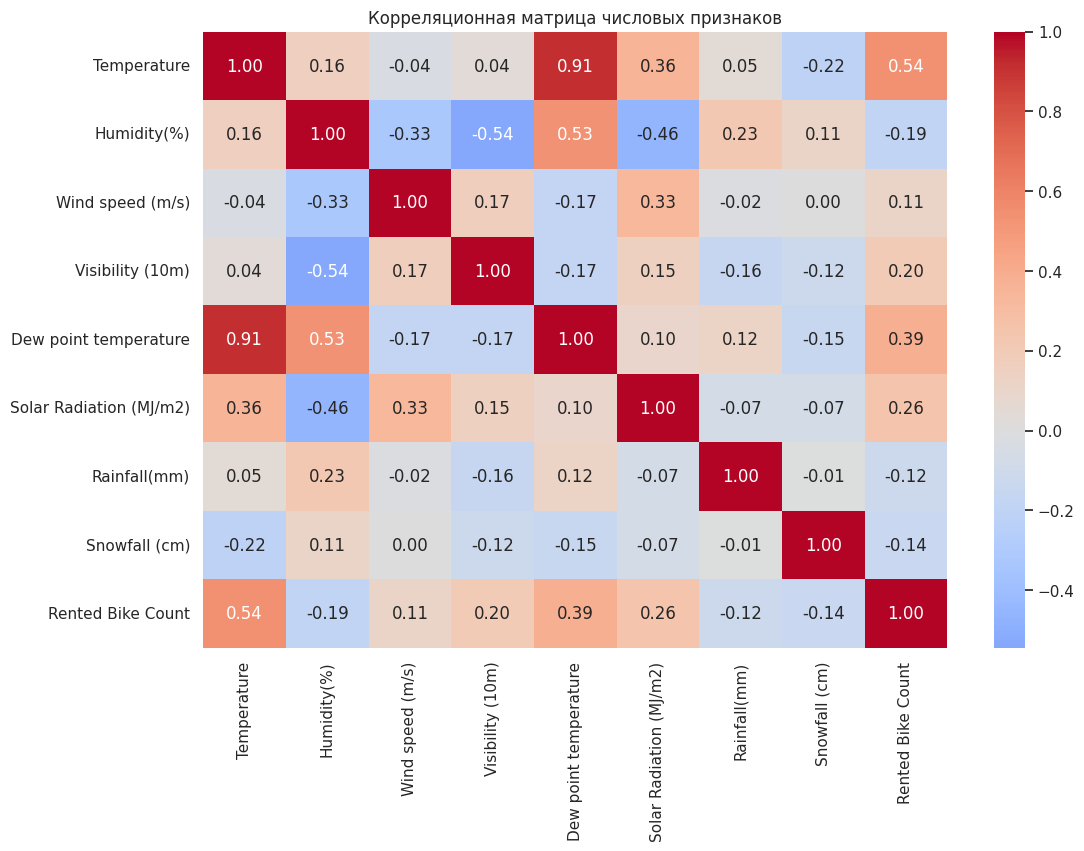

In [27]:
# Корреляционная матрица числовых признаков

corr_matrix = eda_df[num_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

### Промежуточные выводы по исследовательскому анализу

Целевая переменная `Rented Bike Count` имеет асимметричное распределение: среднее значение составляет около **706**, медиана — около **505**, а максимум достигает **3556** аренд. Это говорит о наличии часов с очень высоким спросом, которые могут восприниматься как выбросы с точки зрения статистики, но в бизнес-контексте такие наблюдения важны: именно в периоды пикового спроса компании особенно важно корректно распределять велосипеды.

Доля наблюдений с нулевым спросом составляет **3.45%**. Все наблюдения с `Functioning Day = No` имеют нулевой спрос. Это важный признак: если велопрокат не работает, аренды не происходят. Поэтому `Functioning Day` необходимо обязательно сохранить в модели.

Спрос заметно различается по сезонам. Самый высокий средний спрос наблюдается летом — около **1046** аренд, затем осенью — около **821**, весной — около **725**. Зимой спрос значительно ниже — около **226** аренд. Это подтверждает наличие выраженной сезонности.

В праздничные дни средний спрос ниже, чем в непраздничные: около **494** против **716**. Вероятно, структура поездок в праздники отличается от обычных дней, поэтому признак `Holiday` также может быть полезен для модели.

Спрос также зависит от периода суток. Самый высокий средний спрос наблюдается вечером — около **1194**, затем поздним вечером — около **927**. Ночью спрос существенно ниже — около **289**. Это говорит о важности признаков, связанных со временем суток.

Среди числовых признаков наиболее сильная положительная линейная связь с целевой переменной наблюдается у температуры: коэффициент корреляции около **0.54**. Также положительно связаны со спросом температура точки росы, солнечная радиация и видимость. Влажность, дождь и снег имеют отрицательную связь со спросом.

При этом корреляция отражает только линейные связи. Для этой задачи важны возможные нелинейные зависимости и взаимодействия признаков: например, сочетание высокой температуры, влажности, осадков и времени суток. Поэтому далее будут использованы нелинейные модели `KNeighborsRegressor` и `DecisionTreeRegressor`.

**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---



In [28]:
# Чтобы названия оставались теми же

y_bins = pd.qcut(
    y_train,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train_part, X_valid, y_train_part, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bins)

In [29]:
# Проверка распределения целевой переменной после разделения

target_split_stats = pd.DataFrame({
    "train": y_train_part.describe(),
    "valid": y_valid.describe()
})

target_split_stats

,train,valid
count,5606.000,1402.000
mean,705.773,704.937
std,645.715,648.925
min,0.000,0.000
25%,191.000,190.000
50%,504.000,505.000
75%,1069.000,1072.500
max,3556.000,3404.000


**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



### +Реализация дополнительного задания

In [30]:
class WeatherFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Кастомный трансформер для создания дополнительных погодных признаков.
    
    Трансформер добавляет признаки,
    которые могут помочь нелинейным моделям лучше учитывать погодный контекст.
    """
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X["Has_Rain"] = (X["Rainfall(mm)"].fillna(0) > 0).astype(int)
        X["Has_Snow"] = (X["Snowfall (cm)"].fillna(0) > 0).astype(int)
        X["Has_Precipitation"] = (
            (X["Rainfall(mm)"].fillna(0) > 0) |
            (X["Snowfall (cm)"].fillna(0) > 0)
        ).astype(int)
        
        X["Temp_Humidity_Interaction"] = (
            X["Temperature"] * X["Humidity(%)"]
        )
        
        return X

In [ ]:
engineered_num_features = [
    "Has_Rain",
    "Has_Snow",
    "Has_Precipitation",
    "Temp_Humidity_Interaction"
]

all_num_features = num_features + engineered_num_features

In [33]:
# Словари для удобства (чтобы не потерять и не перепутать)

FEATURES = {
    'num': all_num_features,
    'cat': cat_features,
    'bin': binary_features
}

SPLITS = {
    'X_train_full': X_train,
    'y_train_full': y_train,
    'X_train_part': X_train_part,
    'y_train_part': y_train_part,
    'X_valid': X_valid,
    'y_valid': y_valid,
    'X_test': X_test,
    'y_test': y_test
}

In [34]:
# Пайплайн обработки числовых признаков
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Пайплайн обработки категориальных признаков
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, all_num_features),
        ("cat", cat_transformer, cat_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [36]:
# Пайплайны моделей

knn_pipeline = Pipeline(
    steps=[
        ("feature_engineering", WeatherFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]
)

tree_pipeline = Pipeline(
    steps=[
        ("feature_engineering", WeatherFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=10,
            random_state=RANDOM_STATE
        ))
    ]
)

In [ ]:
# Обучение базовой версии kNN

knn_pipeline.fit(X_train_part, y_train_part)
knn_valid_pred = knn_pipeline.predict(X_valid)

knn_valid_metrics = calculate_metrics(y_valid, knn_valid_pred)

knn_valid_metrics

{'RMSE': 313.9283592642701,
 'MAE': 208.90114122681885,
 'R2': 0.7658026054290181}

In [38]:
# Обучение базовой версии дерева решений

tree_pipeline.fit(X_train_part, y_train_part)
tree_valid_pred = tree_pipeline.predict(X_valid)

tree_valid_metrics = calculate_metrics(y_valid, tree_valid_pred)

tree_valid_metrics

{'RMSE': 317.70180570201603,
 'MAE': 208.36309167262365,
 'R2': 0.7601386215162136}

### Вывод по обучению базовых нелинейных моделей

На этом шаге были подготовлены и проверены первые версии пайплайнов для двух нелинейных моделей:

- `KNeighborsRegressor`;
- `DecisionTreeRegressor`.

В каждый пайплайн были включены:

- кастомный трансформер `WeatherFeatureEngineer` для создания дополнительных погодных признаков;
- обработка пропусков;
- масштабирование числовых признаков;
- кодирование категориальных признаков;
- модель регрессии с базовыми параметрами.

Обе модели успешно обучились на обучающей части тренировочной выборки и сделали предсказания на валидационной выборке.

Промежуточные результаты на validation-выборке:

| Модель | RMSE | MAE | R² |
|---|---:|---:|---:|
| kNN | 313.928 | 208.901 | 0.766 |
| Decision Tree | 317.702 | 208.363 | 0.760 |

Обе модели показали качество выше baseline-модели линейной регрессии. Особенно заметно снизились RMSE и MAE, а значение R² выросло примерно до 0.76. Это подтверждает гипотезу о том, что в данных есть нелинейные зависимости, которые линейная регрессия учитывает недостаточно хорошо.

На текущем этапе `KNeighborsRegressor` показывает немного меньший RMSE, а `DecisionTreeRegressor` — немного меньший MAE. Разница между моделями небольшая, поэтому окончательный выбор делать рано.

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



In [39]:
# Единая схема кросс-валидации для Optuna

cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

### +Продолжаю экспериментировать с классами

In [40]:
class OptunaRegressorOptimizer:
    """
    Класс для подбора гиперпараметров регрессионной модели с помощью Optuna.
    
    Класс принимает базовый sklearn Pipeline, функцию с пространством поиска
    гиперпараметров и оптимизирует модель по RMSE на кросс-валидации.
    """
    
    def __init__(
        self,
        pipeline,
        param_func,
        model_name,
        cv,
        scoring="neg_root_mean_squared_error",
        n_trials=30,
        random_state=42
    ):
        self.pipeline = pipeline
        self.param_func = param_func
        self.model_name = model_name
        self.cv = cv
        self.scoring = scoring
        self.n_trials = n_trials
        self.random_state = random_state
        
        self.study = None
        self.best_params = None
        self.best_score = None
        self.best_pipeline = None
    
    def objective(self, trial):
        params = self.param_func(trial)
        
        model_pipeline = clone(self.pipeline)
        model_pipeline.set_params(**params)
        
        scores = cross_val_score(
            model_pipeline,
            X_train,
            y_train,
            cv=self.cv,
            scoring=self.scoring,
            n_jobs=-1
        )
        
        rmse = -scores.mean()
        return rmse
    
    def optimize(self):
        sampler = optuna.samplers.TPESampler(seed=self.random_state)
        
        self.study = optuna.create_study(
            direction="minimize",
            sampler=sampler,
            study_name=self.model_name
        )
        
        self.study.optimize(
            self.objective,
            n_trials=self.n_trials,
            show_progress_bar=True
        )
        
        self.best_params = self.study.best_params
        self.best_score = self.study.best_value
        
        self.best_pipeline = clone(self.pipeline)
        self.best_pipeline.set_params(**self.best_params)
        
        return self.best_params, self.best_score
    
    def show_best_result(self):
        print(f"Модель: {self.model_name}")
        print(f"Лучший RMSE на CV: {self.best_score:.3f}")
        print("Лучшие параметры:")
        display(self.best_params)

In [41]:
# Пространство поиска гиперпараметров для KNeighborsRegressor.

def suggest_knn_params(trial):
    return {
        "model__n_neighbors": trial.suggest_int("model__n_neighbors", 3, 60),
        "model__weights": trial.suggest_categorical(
            "model__weights",
            ["uniform", "distance"]
        ),
        "model__p": trial.suggest_categorical(
            "model__p",
            [1, 2]
        ),
        "model__leaf_size": trial.suggest_int("model__leaf_size", 10, 60)
    }

In [42]:
# Пространство поиска гиперпараметров для DecisionTreeRegressor.

def suggest_tree_params(trial):
    return {
        "model__max_depth": trial.suggest_int("model__max_depth", 3, 30),
        "model__min_samples_split": trial.suggest_int("model__min_samples_split", 2, 30),
        "model__min_samples_leaf": trial.suggest_int("model__min_samples_leaf", 1, 20),
        "model__max_features": trial.suggest_categorical(
            "model__max_features",
            [None, "sqrt", "log2"]
        ),
        "model__criterion": trial.suggest_categorical(
            "model__criterion",
            ["squared_error", "friedman_mse"]
        )
    }

In [43]:
# Запусок Optuna для kNN

knn_optimizer = OptunaRegressorOptimizer(
    pipeline=knn_pipeline,
    param_func=suggest_knn_params,
    model_name="KNeighborsRegressor",
    cv=cv,
    n_trials=50,
    random_state=RANDOM_STATE
)

best_knn_params, best_knn_rmse = knn_optimizer.optimize()

knn_optimizer.show_best_result()

Best trial: 21. Best value: 302.693: 100%|██████████| 50/50 [00:18<00:00,  2.71it/s]

Модель: KNeighborsRegressor
Лучший RMSE на CV: 302.693
Лучшие параметры:


{'model__n_neighbors': 10,
 'model__weights': 'distance',
 'model__p': 1,
 'model__leaf_size': 47}

In [44]:
tree_optimizer = OptunaRegressorOptimizer(
    pipeline=tree_pipeline,
    param_func=suggest_tree_params,
    model_name="DecisionTreeRegressor",
    cv=cv,
    n_trials=50,
    random_state=RANDOM_STATE
)

best_tree_params, best_tree_rmse = tree_optimizer.optimize()

tree_optimizer.show_best_result()

Best trial: 41. Best value: 319.434: 100%|██████████| 50/50 [00:07<00:00,  7.05it/s]

Модель: DecisionTreeRegressor
Лучший RMSE на CV: 319.434
Лучшие параметры:


{'model__max_depth': 13,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 18,
 'model__max_features': None,
 'model__criterion': 'friedman_mse'}

In [45]:
best_knn_pipeline = knn_optimizer.best_pipeline
best_tree_pipeline = tree_optimizer.best_pipeline

best_params_summary = pd.DataFrame(
    [
        {
            "model": "KNeighborsRegressor",
            "best_cv_rmse": best_knn_rmse,
            "best_params": best_knn_params
        },
        {
            "model": "DecisionTreeRegressor",
            "best_cv_rmse": best_tree_rmse,
            "best_params": best_tree_params
        }
    ]
)

best_params_summary

,model,best_cv_rmse,best_params
0,KNeighborsRegressor,302.693,"{'model__n_neighbors': 10, 'model__weights': '..."
1,DecisionTreeRegressor,319.434,"{'model__max_depth': 13, 'model__min_samples_s..."


In [46]:
best_knn_pipeline.fit(X_train_part, y_train_part)
best_knn_valid_pred = best_knn_pipeline.predict(X_valid)

best_tree_pipeline.fit(X_train_part, y_train_part)
best_tree_valid_pred = best_tree_pipeline.predict(X_valid)

optimized_valid_metrics = pd.DataFrame(
    [
        {
            "model": "Optimized KNeighborsRegressor",
            "sample": "validation",
            **calculate_metrics(y_valid, best_knn_valid_pred)
        },
        {
            "model": "Optimized DecisionTreeRegressor",
            "sample": "validation",
            **calculate_metrics(y_valid, best_tree_valid_pred)
        }
    ]
)

optimized_valid_metrics

,model,sample,RMSE,MAE,R2
0,Optimized KNeighborsRegressor,validation,289.472,197.620,0.801
1,Optimized DecisionTreeRegressor,validation,316.513,211.291,0.762


In [ ]:
PARAMS = {
    'best_knn_pipeline': best_knn_pipeline,
    'best_tree_pipeline': best_tree_pipeline,
    'best_knn_params': best_knn_params,
    'best_tree_params': best_tree_params,
    'best_knn_rmse': best_knn_rmse,
    'best_tree_rmse': best_tree_rmse
}

### Вывод по подбору гиперпараметров

Для моделей `KNeighborsRegressor` и `DecisionTreeRegressor` был выполнен подбор гиперпараметров с помощью библиотеки `Optuna`.

Оптимизация проводилась на тренировочной выборке с использованием единой схемы кросс-валидации:

- количество фолдов: **5**;
- основная метрика оптимизации: **RMSE**;
- направление оптимизации: минимизация RMSE.

Тестовая выборка на данном этапе не использовалась.

Для `KNeighborsRegressor` лучшее значение RMSE на кросс-валидации составило **302.693**. Лучшие параметры:

```python
{
    'model__n_neighbors': 10,
    'model__weights': 'distance',
    'model__p': 1,
    'model__leaf_size': 47
}

**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

